In [3]:
!pip3 install pillow-heif -q


[notice] A new release of pip is available: 25.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


# **AutoEncoders and hidden states Analysis**

Hello, friends!  

In this tutorial, we will explore the idea of using autoencoders for analyzing and extracting features from the hidden states of a model.  

By following this tutorial, you will:  

- Learn or review how feature extraction works in Vision Transformers (ViTs);  
- Build and apply an autoencoder to compress the hidden representations learned by a ViT model in a cat-vs-dog classification task;  
- Compare ViT and PCA for this task.  

Let's get started!  

### **Feature Extraction in ViT**  

Before analyzing hidden representations, we need to understand what we are working with. In a previous tutorial on text transformers, [Probing GPT model](https://habr.com/ru/articles/885076/), feature extraction was based on analyzing vector representations of words.  

For text, the hidden state had the following shape: `(batch_size, sequence_length, hidden_dim)`. For a single input—for example, a sentence with 6 tokens—the shape would be `(1, 6, 1024)`, meaning 6 tokens, each represented as a 1024-dimensional vector.  

Thus, when working with text, we deal with 1D token vectors of fixed length. But what about images?  

### **Images as Features: The Idea of Patches**  

A basic and intuitive approach to representing an image in a form suitable for analysis and vectorization is to flatten it into a 1D vector. For example, an 8×8 image, when flattened, becomes a vector of length 64.  

However, this approach quickly becomes impractical for larger images. If an image is 64×64, flattening results in a vector of length 4096. Moreover, each pixel would need to be connected to every other pixel, leading to \( 4096^2 \) connections.  

So, we need a solution that:  
- Represents each image with multiple vectors;  
- Ensures that each vector has a fixed and manageable (predefined) dimensionality.  

### **Patches in ViT**  

In **Vision Transformers (ViTs)**—one of the key architectures introduced in 2021 ([paper](https://arxiv.org/abs/2010.11929))—these challenges are addressed using **patches**.  

The process of creating patches works as follows:  

1. Take an image of shape \( H, W, C \), where \( H \) is the height, \( W \) is the width, and \( C \) is the number of channels.  
2. Split it into \( N \) patches. Each patch is a square of size \( p \times p \times C \), where \( p \) is the patch size.  
3. Flatten these patches into vectors, resulting in \( N \) vectors of size \( p^2 \times C \).  
4. Multiply the array of patches \( (N, p^2 \times C) \) by a learnable tensor of shape \( (p^2 \times C, d) \).  
5. This results in \( N \) patch embeddings of size \( (1, d) \).  
6. Add a **[CLS] token**, similar to BERT (see [this explanation](https://stackoverflow.com/questions/62705268/why-bert-transformer-uses-cls-token-for-classification-instead-of-average-over)), with shape \( (1, d) \), making the input size \( (N+1, d) \).  
7. Finally, add a **positional embedding** of the same shape \( (1, d) \) to each patch.  

At this point, the extracted features are ready to be processed by the transformer encoder.  

![patches](https://user-images.githubusercontent.com/42609155/128160932-6c92920e-b996-4208-9f71-c5caeb4d7285.png)  

### **How Many Vectors Represent an Image and What Is Their Size?**  

The dimensionality of each feature vector (i.e., \( d \) in the notation above) in ViT is a fixed parameter. Typically, the feature vector has a length of **768**.  

For an input image with a **single** channel and dimensions \( (h, w) = (224, 224) \), the number of vectors representing it depends on:  

1. The number of patches \( k \)  
2. The patch size \( p \)  

These parameters are chosen so that \( h = w = p \cdot k \). If we use **14 patches**, as in the example, the number of feature vectors is:  

\[
\text{cnt} = \frac{h}{p} \times \frac{w}{p} = k \times k = 14 \times 14 = 196
\]  

The image is split using a **convolution operation** with a kernel size of \( (p, p) \) and a stride of \( (p, p) \).  

Thus, our image is ultimately represented by **197 vectors** (196 for the patches + 1 for the CLS token), each of size **768**!  


### **Practice**  

Now that we understand how features are formed, let's move on to the practical part.  


In [13]:
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import os
import requests
import matplotlib.pyplot as plt
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from io import BytesIO
from tqdm import tqdm
from pillow_heif import register_heif_opener # for HEIC images (1)

register_heif_opener() # for HEIC images (2)

Now let's load the model and the picture. Let's start with the picture. These are my cats =).

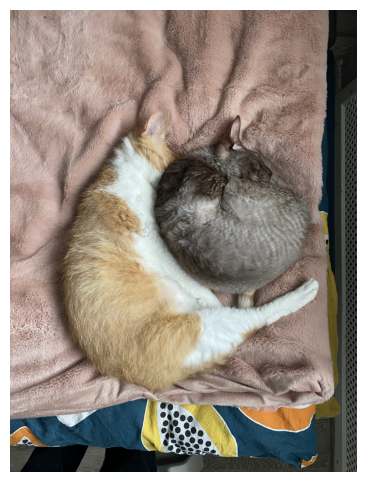

In [14]:
# Load Image
url = 'https://github.com/SadSabrina/XAI-open_materials/blob/main/VIT_and_autoencoders/IMG_8625.HEIC?raw=true'
image_bytes = requests.get(url).content
image = Image.open(BytesIO(image_bytes))
                   

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(image)
plt.axis('off');

The model is taken from here: [ViT Cats vs Dogs](https://huggingface.co/akahana/vit-base-cats-vs-dogs).  
You can load the model from Hugging Face — this option is already included in the code.  

If that doesn't work, you need to:  
1. Download the `cat_dog_model` folder from [this link](https://drive.google.com/drive/folders/1TztlM4sC0HRJmhZyMltRIGZP1exGRHt5?usp=sharing).  
2. Specify the folder path in `MODEL_PATH`.  
3


In [16]:
MODEL_PATH = 'your_path_here'
MODEL_PATH_HF = 'akahana/vit-base-cats-vs-dogs'

#  Load the pre-trained feature extractor and classification model
feature_extractor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
model = ViTForImageClassification.from_pretrained(MODEL_PATH_HF)
model.eval()

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTSdpaAttention(
            (attention): ViTSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_fe

We transform the input image into features using `ViTImageProcessor`.

In [18]:
# Preparing input data
inputs = feature_extractor(images=image, return_tensors="pt")


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.96862745].


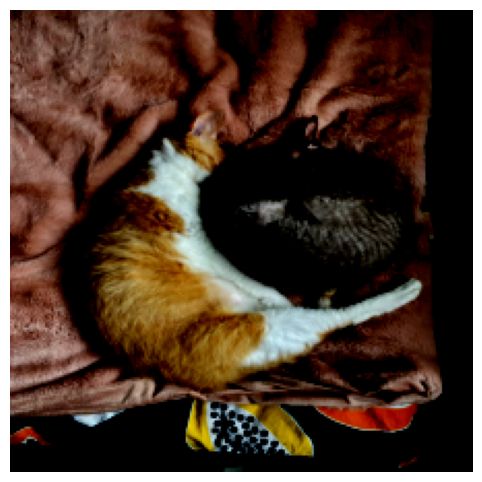

In [19]:
# image after taking features

featured_image = inputs['pixel_values'][0].permute(1, 2, 0)

fig, ax = plt.subplots(figsize=(12, 6))
plt.imshow(featured_image)
plt.axis('off');

### **Step 1. Model analysis**

Before extracting features, assuming we already know their dimensions, we need to understand where they will be taken from. To do this, let's examine the model structure.  

We don't have to implement the extraction manually since hidden states can be obtained by specifying a hyperparameter during model inference.  


In [9]:
model.vit

ViTModel(
  (embeddings): ViTEmbeddings(
    (patch_embeddings): ViTPatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): ViTEncoder(
    (layer): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (attention): ViTSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): ViTSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (intermediate): ViTIntermediate(
          (dense): Linear(in_features=768, out_features=3072, bias=True)
          (intermediate_act_fn): GELUActivation()
        )
        (output): ViTOutput(
          (d

In [20]:
model.classifier

# # Try to understand how many layers are in the encoder? Uncomment the code below to get the answer
# print(len(model.vit.encoder._modules['layer']))

Linear(in_features=768, out_features=2, bias=True)

So, the basic model consists of a sequence of encoders and a classifier. Let's try to understand what hidden states will be.



In [21]:
# prediction
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

# Get predicted class
predicted_class_idx = outputs.logits.argmax(-1).item()
labels = model.config.id2label  # class2index dict

print(f"Predicted index: {labels[predicted_class_idx]}")

Predicted index: cat


In [22]:
print(f'Number of hidden states: {len(outputs.hidden_states)}')
print(f'Shape of each state: {outputs.hidden_states[0].shape}')

Number of hidden states: 13
Shape of each state: torch.Size([1, 197, 768])


The number of hidden states is 13, where:

* The first one (`outputs.hidden_states[0]`) is the output of the `model.vit.embeddings` part.
* States 2-13 are the outputs of the encoder layers—everything before applying the final `layernorm` component to `model.vit`.

**Important:**  

In some models, when specifying `output_hidden_states=True`, the `last_hidden_state` is also returned. In general, `outputs.last_hidden_state != outputs.hidden_states[-1]`, because what is stored in `outputs.last_hidden_state` reflects the hidden state after the `layernorm`.  


Now that we understand the output for one image, we can process several. For example, 300 cats and dogs — they will take about 5 minutes to process. You can use more if running locally on a good laptop).  

To proceed, you can download the data from [here](https://drive.google.com/drive/folders/1TztlM4sC0HRJmhZyMltRIGZP1exGRHt5?usp=sharing).


In [15]:
# IMAGE PATH
image_folder = "your path_here"


# hidden states lists
last_hidden_states_list = []
mid_hidden_states_list = []
labels_list = []

# Loop through all files in the folder
for filename in tqdm(os.listdir(image_folder)[:300]):
    if filename.endswith((".jpg", ".png", ".jpeg")):  # Filter images
        image_path = os.path.join(image_folder, filename)
        image = Image.open(image_path).convert("RGB")  ## Open image


        # Обрабатываем изображение с помощью feature extractor
        inputs = feature_extractor(images=image, return_tensors="pt")

         # Get hidden states
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            features = model.vit(**inputs).last_hidden_state[:, 1:, :] # Image representation before being fed into the classifier
            mid_features = outputs.hidden_states[len(outputs.hidden_states) // 2][:, 1:, :]  # Last layer (dimension: batch x patches x hidden_dim)

        predicted_class_idx = outputs.logits.argmax(-1).item()
        labels = model.config.id2label  # Dictionary of class indices and labels
        label = labels[predicted_class_idx]

        # Add hidden states and label to the list
        last_hidden_states_list.append(features.squeeze(0))  ## Remove batch dimension
        mid_hidden_states_list.append(mid_features.squeeze(0))
        labels_list.append(label)



100%|██████████| 300/300 [08:17<00:00,  1.66s/it]


In [16]:
# hidden states to tensors
last_hidden_states_tensor = torch.stack(last_hidden_states_list)  # Shape: (num_images, hidden_dim)

mid_hidden_states_tensor = torch.stack(mid_hidden_states_list)

Now, let's summarize what we have. For each of the 300 images, we have a matrix of size $197 \times 768$. Analyzing features in this format and trying to separate them for the two classes is not convenient. How can we determine whether the model has separated the classes in the feature space?

For this, we can apply an autoencoder!



### **Autoencoder, Brief Overview**  

**Autoencoders** are neural networks with a special architecture, where the key component is feature compression into a hidden space. Initially, this hidden space wasn't intended for XAI (and in 1986, when the idea of autoencoders was introduced, there wasn't even a problem with black-box models), but recent research by [OpenAI](https://openai.com/index/extracting-concepts-from-gpt-4/) (and others) has shown the potential of this architecture in the field of interpretability.  

The simplest autoencoder looks like [this](https://en.wikipedia.org/wiki/Autoencoder) (wiki link).

We will implement it in code as two components, as shown in the image — the encoder and the decoder. For them, we will write simple classes based on this logic.  

We have 196 patches, each with 768 features. The number of patches represents the number of features, and reducing this number would be incorrect. Therefore, we will work with the dimension of the hidden representation — 768.


In [17]:
class PatchEncoder(nn.Module):
    def __init__(self, D_latent=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(768, 512, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(512, 256, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(256, 128, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(128, 64, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(64, 32, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(32, 16, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(16, 8, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(8, 4, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(4, D_latent, kernel_size=1), # [B, 196, D_latent].

        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, 768, 196] для Conv1d
        return self.encoder(x).permute(0, 2, 1)  # [B, 196, D_latent]


class PatchDecoder(nn.Module):
    def __init__(self, D_latent=128):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Conv1d(D_latent, 4, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(4, 8, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(8, 16, kernel_size=1),  # Recovering the dimension
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(256, 512, kernel_size=1),
            nn.ReLU(),
            nn.Conv1d(512, 768, kernel_size=1)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, D_latent, 196]
        return self.decoder(x).permute(0, 2, 1)  # [B, 196, 768]


class PatchAutoencoder(nn.Module):
    def __init__(self, D_latent=128):
        super().__init__()
        self.encoder = PatchEncoder(D_latent)
        self.decoder = PatchDecoder(D_latent)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

The model is ready. In it, we progressively reduce the features using convolution. When applying the autoencoder to the hidden states, the idea is as follows:

*If the autoencoder is able to converge during training, we will obtain a representation that reflects the compressed features from the model*.

Alright. Now let's prepare the data and train the autoencoder.


### **Data Preparation**

When extracting features, we will rely not on the ground truth classes, but on those predicted by the model. We have collected these predictions above.

**Why is this approach used?**  
The task of feature extraction is always related to extracting information *from the model*, meaning it is correct to rely only on the information embedded in the model. The hypothesis in feature analysis is that the predicted class corresponds to the "opinion" of the model based on its knowledge of the image.


In [18]:
# Classes

func = lambda x: 1 if x =='cat' else 0
inv_func = lambda x: 'cat' if x == 1 else 'dog'

labels_list = [func(i) for i in labels_list]

In [ ]:
labels_tensor = torch.tensor(labels_list)  # (num_images,)

# Save hidden states and labels so you don't have to get them again every time
torch.save(last_hidden_states_tensor, "last_hidden_states.pt")
torch.save(mid_hidden_states_tensor, "mid_last_hidden_states.pt")

torch.save(labels_tensor, "labels.pt")

print(f"Saved {len(last_hidden_states_tensor)} hidden states. Tensor shape: {last_hidden_states_tensor.shape}")
print(f"Saved {len(mid_hidden_states_tensor)} hidden states. Tensor shape:  {mid_hidden_states_tensor.shape}")

Run training on hidden states. Above we collected the last two (in `last_hidden_states_list`) and the middle one (in `mid_hidden_states_list`)

In [20]:
autoencoder = PatchAutoencoder(D_latent=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)
num_epochs = 10

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = autoencoder(last_hidden_states_tensor)  # [B, 196, 768]
    loss = criterion(outputs, last_hidden_states_tensor)
    loss.backward()
    optimizer.step()
    print(loss)

tensor(0.0452, grad_fn=<MseLossBackward0>)
tensor(0.0451, grad_fn=<MseLossBackward0>)
tensor(0.0450, grad_fn=<MseLossBackward0>)
tensor(0.0449, grad_fn=<MseLossBackward0>)
tensor(0.0448, grad_fn=<MseLossBackward0>)
tensor(0.0447, grad_fn=<MseLossBackward0>)
tensor(0.0446, grad_fn=<MseLossBackward0>)
tensor(0.0445, grad_fn=<MseLossBackward0>)
tensor(0.0444, grad_fn=<MseLossBackward0>)
tensor(0.0444, grad_fn=<MseLossBackward0>)


Judging by the decrease in the loss, the training has been completed. It hasn't deviated significantly from the starting point, but the result is worth checking.


Now, let's extract the hidden representations and take the median across the patches to obtain a matrix of size $m \times n$, where $m$ is the number of rows (examples), and $n$ is the median of each patch.


In [21]:
latent = autoencoder.encoder(last_hidden_states_tensor)
latent_med = np.median(latent.detach().numpy(), axis=1)
latent_med.shape

(300, 2)

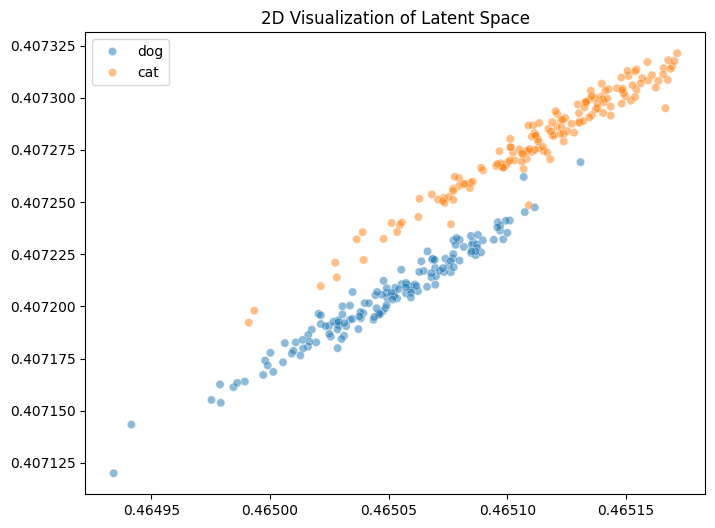

In [22]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=latent_med[:, 0], y=latent_med[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.title("2D Visualization of Latent Space")
plt.show()

Now, let's see if there will be a similar clear separation in the middle hidden layers.


In [23]:
# Middle patches

mid_autoencoder = PatchAutoencoder(D_latent=2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-2)
num_epochs = 10

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = mid_autoencoder(mid_hidden_states_tensor)  # [B, 196, 768]
    loss = criterion(outputs, mid_hidden_states_tensor)
    loss.backward()
    optimizer.step()
    print(loss)

tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)
tensor(66.5882, grad_fn=<MseLossBackward0>)


In [24]:
mid_latent = mid_autoencoder.encoder(mid_hidden_states_tensor)
mid_latent_med = np.median(mid_latent.detach().numpy(), axis=1)
mid_latent_med.shape

(300, 2)

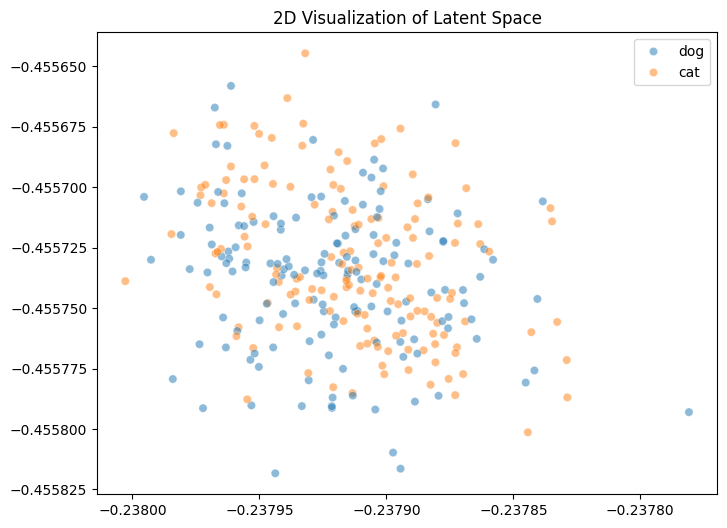

In [25]:
# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=mid_latent_med[:, 0], y=mid_latent_med[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.title("2D Visualization of Latent Space")
plt.show()

In the middle layers, we can only see the beginning of the separation. Additionally, the AE training process isn't progressing.


### **Results and Conclusions**

Let's summarize what we have achieved.

1. First, a pre-trained model was taken.

2. Predictions were extracted for the test data of this model, along with:
   * predictions,
   * hidden states of the last layer,
   * hidden states of the middle layer.

3. An autoencoder was trained on the hidden states, with the central dimensionality between the encoder and decoder components set to 2.

4. The two-component representation was used to assess how well the features of the predicted classes were separated from one another (in two dimensions, so that it could be plotted on a plane).

Visualizations showed that the model clearly separates feature representations in the last hidden state but does so poorly in the middle one. From this, we can hypothesize that there is a gradual distinction as the network depth increases (and that the middle layer doesn't separate classes very well).

**Note:**

In fact, the conclusion from this particular study cannot be generalized for all models, nor can it be assumed that middle hidden states do not encode rich representations. On the contrary, for example, in [Layer by Layer: Uncovering Hidden Representations in Language Models](https://arxiv.org/pdf/2502.02013), the authors show that intermediate layers can encode even richer representations than the final ones, demonstrating good performance across a broad range of sub-tasks. Another interesting example is in [Probing Latent Subspaces in LLM for AI Security: Identifying and Manipulating Adversarial States](https://arxiv.org/pdf/2503.09066), where they extract directions for jailbreaking, again from an intermediate layer.

There is a lot of interesting stuff inside =).

I hope this tutorial will provide some inspiration, showing that working with a trained network can be rich in terms of model analysis!

Thank you for your time!  
As always, the tutorial is on [GitHub](https://github.com/SadSabrina/XAI-open_materials/tree/main/VIT_and_autoencoders) (along with notebooks and other tutorials in the repository).

**Wishing you successful projects!**  
**Your Data-Author!**


### **Note on the Sidelines - PCA**

Let's consider if we really needed the autoencoder.

Principal Component Analysis (PCA) is another effective technique for dimensionality reduction that could have been applied in this context, especially if we are trying to simplify the representation of the hidden states. PCA is a linear method that projects data into a space where the variance of the data is maximized along the new axes, making it a good candidate for identifying the most informative components in the feature space.

Here's why PCA might have been a good alternative to the autoencoder:

1. **Simplicity**: PCA is straightforward and computationally efficient. Unlike autoencoders, which involve training a neural network, PCA can be applied directly to the feature matrix with minimal preparation.

2. **Interpretability**: PCA provides components that directly correspond to the directions of maximum variance in the feature space. 

3. **Dimensionality Reduction**: Just like the autoencoder, PCA can reduce the dimensionality of the feature space. The difference is that PCA does this linearly, whereas the autoencoder is capable of capturing non-linear relationships in the data. However, linear methods like PCA can still perform quite well if the data is linearly separable.

4. **Time and Resources**: PCA requires no training, which saves time and computational resources compared to training an autoencoder, especially if the dataset is large.

In the case of hidden states from the transformer model, applying PCA could help to reduce the complexity of the data and potentially reveal clear separations between the classes. By projecting the data into a lower-dimensional space (say, two or three components), we could plot the data and visually check for separability between classes, just as we attempted to do with the autoencoder.

So, before jumping into the complexity of training an autoencoder, it would have been useful to try PCA as a simpler baseline method to understand the structure of the data. The results from PCA might be comparable to those of the autoencoder, especially when we’re trying to separate classes based on feature representations.

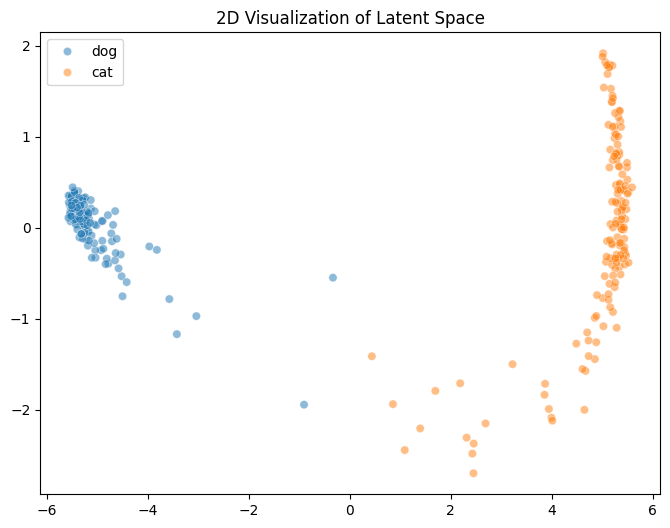

In [26]:
import seaborn as sns
from sklearn.decomposition import PCA

original_hid_states = np.median(last_hidden_states_tensor.detach().numpy(), axis=1)

pca = PCA(n_components=2, random_state=42)
orig_latent_2d = pca.fit_transform(original_hid_states)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=orig_latent_2d[:, 0], y=orig_latent_2d[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.legend()
plt.title("2D Visualization of Latent Space")
plt.show()

In [27]:
pca.explained_variance_ratio_

array([0.8817762 , 0.02155441], dtype=float32)

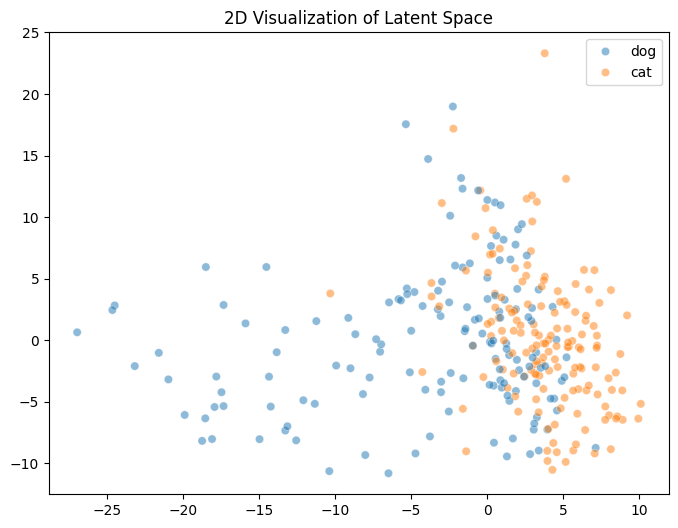

In [28]:
mid_original_hid_states = np.median(mid_hidden_states_tensor.detach().numpy(), axis=1)

pca = PCA(n_components=2, random_state=42)
mid_orig_latent_2d = pca.fit_transform(mid_original_hid_states)

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=mid_orig_latent_2d[:, 0], y=mid_orig_latent_2d[:, 1], hue=[inv_func(i) for i in labels_tensor.detach().numpy()], alpha=0.5)
plt.legend()
plt.title("2D Visualization of Latent Space")
plt.show()

In [29]:
pca.explained_variance_ratio_

array([0.10040888, 0.06792985], dtype=float32)

Exactly — it’s important to remember traditional methods, especially when dealing with simpler models and tasks.

While deep learning models like autoencoders offer powerful non-linear dimensionality reduction capabilities, classical methods such as PCA, t-SNE, or even linear discriminant analysis (LDA) can sometimes provide surprisingly effective solutions, especially when the problem doesn't require the full complexity of neural networks.

For tasks like feature extraction and class separation where the relationships might be relatively simple, these classical techniques can save time and computational resources, providing a transparent and interpretable view of the data. They also serve as excellent baselines that help validate whether more complex models are truly necessary or if simpler methods are sufficient to solve the problem effectively.

In summary, always consider the balance between complexity and interpretability, especially when working with simpler models or datasets, and keep the traditional methods in mind as useful tools for analysis and understanding.

Join my [Telegram channel (rus)](https://t.me/jdata_blog) to stay updated with new releases!

I also invite you to take my [course (rus)](https://stepik.org/a/198640) on explainable AI methods and, of course, I'd be happy to connect with you on [LinkedIn](https://www.linkedin.com/in/sabrina-sadiekh-35181a286/).

Wishing you successful and incredibly beautiful projects!  
Your Data-Author!  